# Results

In [1]:
from pathlib import Path
import re
import pandas as pd

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    possible = Path.cwd() / "vollmers/gnn-thesis/gnn-thesis"
    if (possible / "src").exists():
        PROJECT_ROOT = possible

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXPERIMENT_DIR = PROJECT_ROOT / "outputs" / "experiments"
fold_pattern = re.compile(r"fold_(\d+)_val_predictions\.csv\.gz$")


def load_model_folds(model_name):
    model_dir = EXPERIMENT_DIR / model_name
    frames = []

    for path in sorted(model_dir.glob("fold_*_val_predictions.csv.gz")):
        fold = int(fold_pattern.search(path.name).group(1))

        df = pd.read_csv(path, compression="gzip")
        df["fold"] = fold
        df["model"] = model_name

        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No fold prediction files found in {model_dir}")

    return pd.concat(frames, ignore_index=True)

In [3]:
afp_df = load_model_folds("AttentiveFP-11M-150")

gf_df = load_model_folds("Grapefruitv2-9M150")

gcn_df = load_model_folds("GCN")

gatv2_df = load_model_folds("GATv2")

pna_df = load_model_folds("PNA")

In [4]:
gf_df

,row_id,fold,split,experiment_id,SK_unique_id,species_common_name,species_latin_name,CAS,chemical_name,conc_unit,...,has_metal,is_single_node,fragment_count,log10_mol_weight,formal_charge,butina_group,actual_log10c,pred_log10c,abs_error_log10c,model
0,1,0,val,Grapefruitv2-9M150,RTECS41,mouse,Mus musculus,78111-17-8,"Acanthifolicin, 9,10-deepithio-9,10-didehydro-",mg/kg,...,0.0,0.0,1.0,2.905508,0.0,cluster::72101,-0.716699,-0.112295,0.604404,Grapefruitv2-9M150
1,3,0,val,Grapefruitv2-9M150,RTECS140,mouse,Mus musculus,102585-20-6,"5-Acenaphthenamine, 6,7,8,8a-tetrahydro-N-(2-o...",mg/kg,...,0.0,0.0,1.0,2.384070,0.0,cluster::72099,2.000000,1.450071,0.549929,Grapefruitv2-9M150
2,4,0,val,Grapefruitv2-9M150,RTECS141,rat,Rattus norvegicus,83-32-9,Acenaphthene,mg/kg,...,0.0,0.0,1.0,2.187741,0.0,cluster::72098,2.778151,2.861958,0.083806,Grapefruitv2-9M150
3,10,0,val,Grapefruitv2-9M150,RTECS181,mouse,Mus musculus,102585-21-7,"Acenaphtho(1,2-b)thiophene, 6b,8,9,9a-tetrahyd...",mg/kg,...,0.0,0.0,1.0,2.453362,0.0,cluster::72092,1.875061,1.977345,0.102284,Grapefruitv2-9M150
4,15,0,val,Grapefruitv2-9M150,RTECS187,rat,Rattus norvegicus,208-96-8,Acenaphthylene,mg/kg,...,0.0,0.0,1.0,2.182022,0.0,cluster::72087,3.222717,2.987753,0.234963,Grapefruitv2-9M150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525847,525826,4,val,Grapefruitv2-9M150,AQTER1441825,Coffee Borer Beetle,hypothenemus hampei,173072-61-2,O-(4-Bromo-2-chlorophenyl) O-ethyl S-propyl es...,kg/m2,...,0.0,0.0,2.0,2.945426,0.0,cluster::6539,-4.096910,-3.996918,0.099992,Grapefruitv2-9M150
525848,525827,4,val,Grapefruitv2-9M150,AQTER1441828,Coffee Borer Beetle,hypothenemus hampei,173072-61-2,O-(4-Bromo-2-chlorophenyl) O-ethyl S-propyl es...,kg/m2,...,0.0,0.0,2.0,2.945426,0.0,cluster::6539,-4.096910,-3.999184,0.097726,Grapefruitv2-9M150
525849,525828,4,val,Grapefruitv2-9M150,AQTER1441830,Coffee Borer Beetle,hypothenemus hampei,173072-61-2,O-(4-Bromo-2-chlorophenyl) O-ethyl S-propyl es...,kg/m2,...,0.0,0.0,2.0,2.945426,0.0,cluster::6539,-4.096910,-4.023633,0.073277,Grapefruitv2-9M150
525850,525829,4,val,Grapefruitv2-9M150,AQTER1441831,Coffee Borer Beetle,hypothenemus hampei,173072-61-2,O-(4-Bromo-2-chlorophenyl) O-ethyl S-propyl es...,kg/m2,...,0.0,0.0,2.0,2.945426,0.0,cluster::6539,-4.096910,-3.987543,0.109367,Grapefruitv2-9M150


In [5]:
print(afp_df["abs_error_log10c"].median())

print(gf_df["abs_error_log10c"].median())

0.48761803000000004
0.48969977499999995


In [6]:
print(afp_df.loc[afp_df["is_salt"] == 0, "abs_error_log10c"].median())

print(gf_df.loc[afp_df["is_salt"] == 0, "abs_error_log10c"].median())

0.49220085
0.49619767


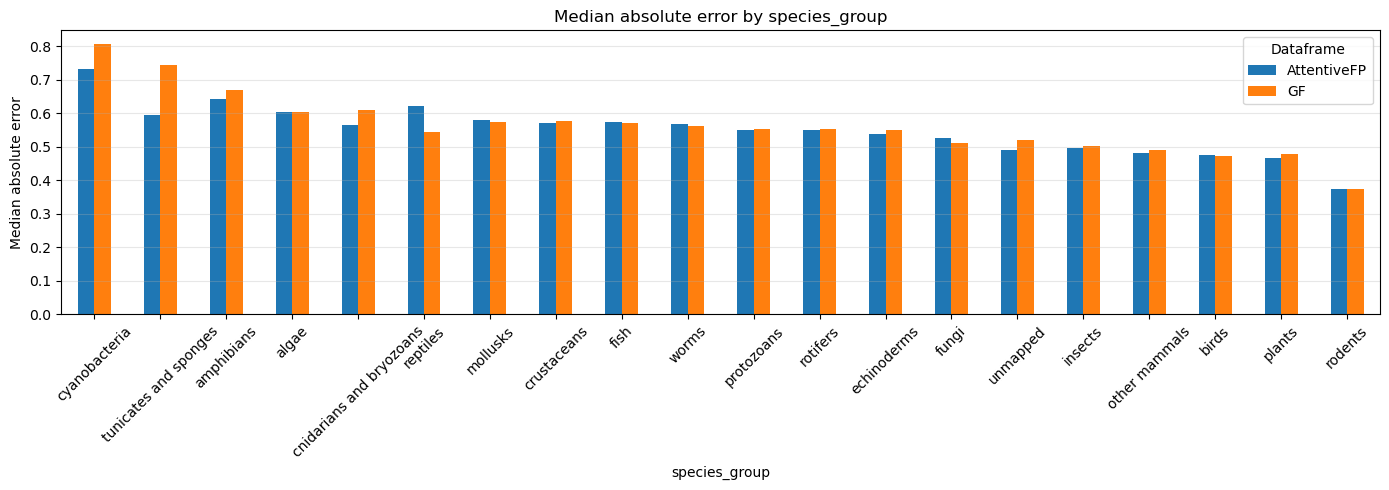

In [8]:
from src.visualization.results import plot_median_abs_error_by_category

summary, ax = plot_median_abs_error_by_category(
    {
        "GF": gf_df,
        "AttentiveFP": afp_df,
        # "GCN": gcn_df,
        # "GATv2": gatv2_df,
        # "PNA": pna_df,
    },
    "species_group",
)

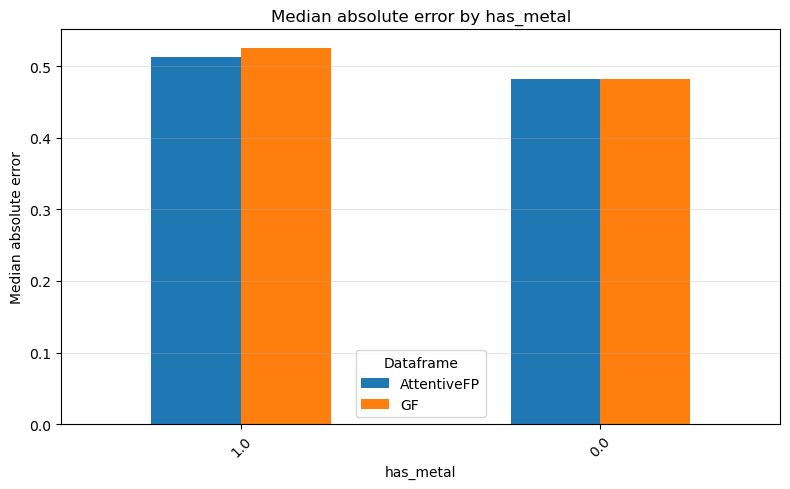

In [9]:
summary, ax = plot_median_abs_error_by_category(
    {
        "GF": gf_df,
        "AttentiveFP": afp_df,
        # "GCN": gcn_df,
        # "GATv2": gatv2_df,
        # "PNA": pna_df,
    },
    ["has_metal"],
)

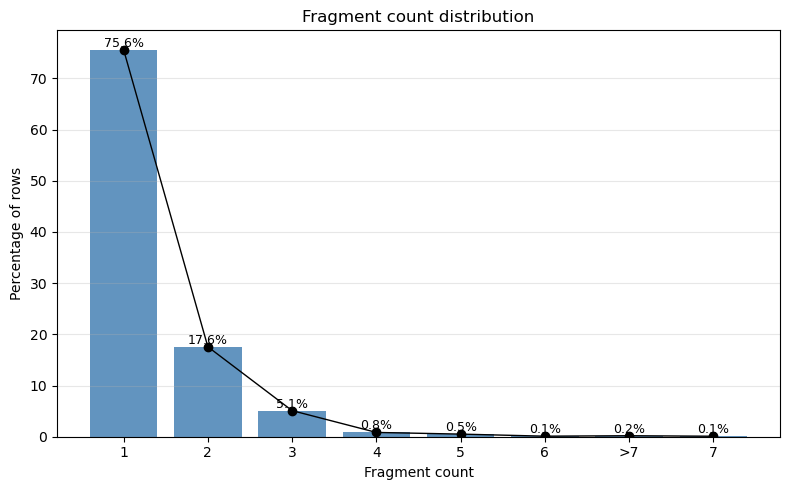

In [16]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_fragment_count_distribution(
    df,
    *,
    fragment_col="fragment_count",
    title="Fragment count distribution",
    max_fragment_count=None,
    figsize=(8, 5),
):
    plot_df = df.copy()
    plot_df[fragment_col] = plot_df[fragment_col].astype(int)

    if max_fragment_count is not None:
        plot_df[fragment_col] = plot_df[fragment_col].where(
            plot_df[fragment_col] <= max_fragment_count,
            other=f">{max_fragment_count}",
        )

    dist = (
        plot_df[fragment_col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percentage")
        .reset_index()
        .rename(columns={"index": fragment_col})
    )

    dist[fragment_col] = dist[fragment_col].astype(str)
    dist = dist.sort_values(
        fragment_col,
        key=lambda s: s.str.replace(">", "", regex=False).astype(int),
    )

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(dist[fragment_col], dist["percentage"], color="steelblue", alpha=0.85)
    ax.plot(dist[fragment_col], dist["percentage"], color="black", marker="o", linewidth=1)

    ax.set_xlabel("Fragment count")
    ax.set_ylabel("Percentage of rows")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    for i, pct in enumerate(dist["percentage"]):
        ax.text(i, pct, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()

    return dist, ax

fragment_dist, ax = plot_fragment_count_distribution(
    afp_df,
    max_fragment_count=7,
    title="Fragment count distribution"
)

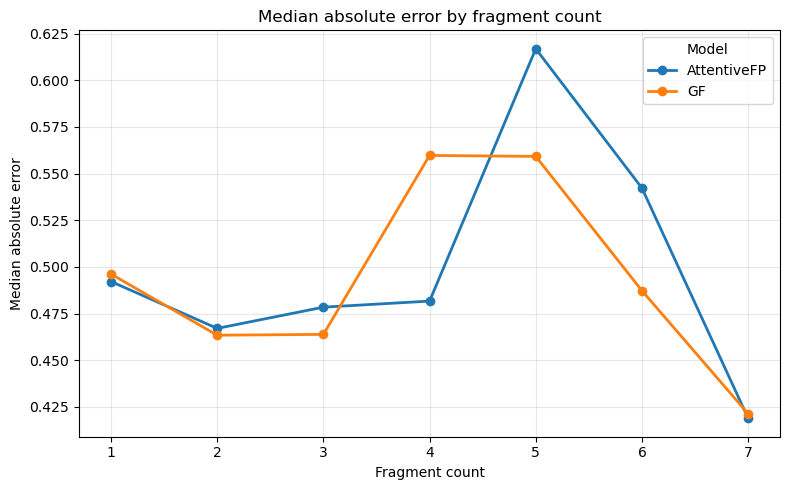

In [10]:
from src.visualization.results import plot_median_ae_by_fragment_count

summary, ax = plot_median_ae_by_fragment_count(
    {
        "GF": gf_df,
        "AttentiveFP": afp_df,
        # "GCN": gcn_df,
        # "GATv2": gatv2_df,
        # "PNA": pna_df,
    },
    max_fragment_count=7,
    min_count=10,
)

/home/vollmers/gnn-thesis/src/visualization/results.py:322: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  work[column] = pd.to_numeric(work[column], errors="ignore")
/home/vollmers/gnn-thesis/src/visualization/results.py:322: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  work[column] = pd.to_numeric(work[column], errors="ignore")


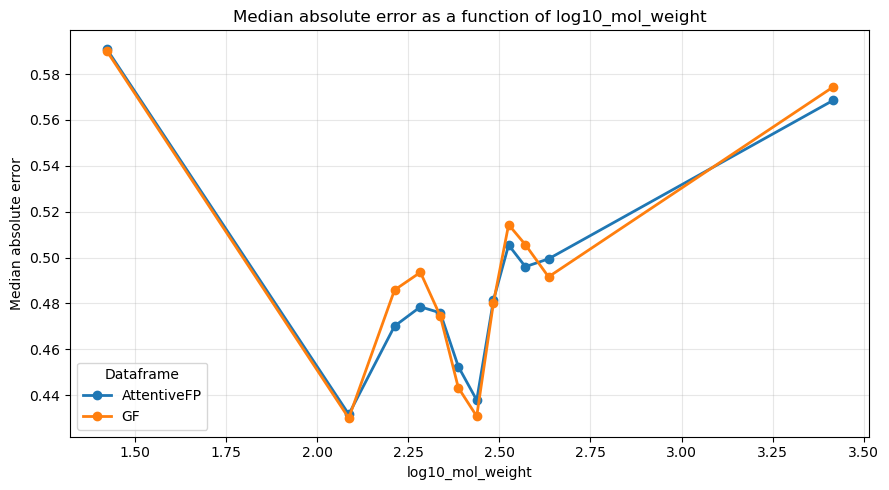

In [12]:
from src.visualization.results import plot_median_ae_by_column


summary, ax = plot_median_ae_by_column(
    {
        "GF": gf_df,
        "AttentiveFP": afp_df,
        # "GCN": gcn_df,
        # "GATv2": gatv2_df,
        # "PNA": pna_df,
    },
    "log10_mol_weight",
    min_count=10,
)

In [13]:
import pandas as pd

def calculate_guessing_average_simulate_CV(
        df: pd.DataFrame, 
        group_by: list[str]=['species_group', 'endpoint', 'effect', 'conc_unit']
        ) -> pd.DataFrame:
    
    guesses = []
    for fold in df.fold.unique():
        df_fold = df[df['fold'] == fold].copy()
        df_other_folds = df[df['fold'] != fold].copy()
        guessing_average = df_other_folds.groupby(group_by, as_index=False)[['labels']].median(numeric_only=True).reset_index(drop=True)
        guesses.append(df_fold.merge(guessing_average, on=group_by, suffixes=('', '_guess_avg'), how='left')['labels_guess_avg'])
    df['preds_guess_avg'] = pd.concat(guesses, ignore_index=True)

    # Sometimes the training set does not contain any samples 
    # for a given species group × endpoint × effect combination, 
    # leading to NA guessing averages. 
    # We can impute these with the overall median of the training set for that fold, 
    # which is a reasonable guess in absence of any other information.

    for fold in df.fold.unique():
        fold_mask = df['fold'] == fold
        num_na = df.loc[fold_mask, 'preds_guess_avg'].isna().sum()
        if num_na > 0:
            overall_median = df.loc[~fold_mask, 'labels'].median()
            df.loc[fold_mask & df['preds_guess_avg'].isna(), 'preds_guess_avg'] = overall_median
            print(f"Fold {fold}: Imputed {num_na} NA guessing averages with overall median {overall_median}")
    return df

In [14]:
guess_df = gf_df.copy()
guess_df["labels"] = guess_df["actual_log10c"]

guess_df = calculate_guessing_average_simulate_CV(guess_df)

guess_df["abs_error_guess_avg_log10c"] = (
    guess_df["actual_log10c"] - guess_df["preds_guess_avg"]
).abs()

guess_df["abs_error_guess_avg_log10c"].median()

Fold 0: Imputed 203 NA guessing averages with overall median 0.69897
Fold 1: Imputed 191 NA guessing averages with overall median 0.69897
Fold 2: Imputed 267 NA guessing averages with overall median 0.6812412
Fold 3: Imputed 196 NA guessing averages with overall median 0.6273658
Fold 4: Imputed 251 NA guessing averages with overall median 0.69897


0.80271943

In [15]:
print("Guessing average:", guess_df["abs_error_guess_avg_log10c"].median())
print("GF:", gf_df["abs_error_log10c"].median())
print("AttentiveFP:", afp_df["abs_error_log10c"].median())
print("GCN:", gcn_df["abs_error_log10c"].median())
print("GATv2:", gatv2_df["abs_error_log10c"].median())
print("PNA:", pna_df["abs_error_log10c"].median())

Guessing average: 0.80271943
GF: 0.48969977499999995
AttentiveFP: 0.48761803000000004
GCN: 0.515029575
GATv2: 0.516638995
PNA: 0.537936815
